# AEMO Evaluation Notebook

This notebook mirrors the evaluation workflow in `test_eval.ipynb`, but it is wired to the AEMO trajectories exported by `aemo_simrun.ipynb`. It loads the AEMO manifest, rehydrates the episode logs, and runs `evaluate_experiments()` on policy-grouped AEMO data.

Use this notebook to inspect AEMO return statistics, recommended RTG / return scale values, and risk-sensitive summary metrics without touching the training notebook. The main evaluation cell groups the raw experiment labels by policy so the plots and summary table stay readable.

In [ ]:
# Repository bootstrap for relocated notebooks
from pathlib import Path
import os
import sys

def _find_repo_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "README.md").exists() and (candidate / "src").exists():
            return candidate
    return start

REPO_ROOT = _find_repo_root(Path.cwd().resolve())
os.chdir(REPO_ROOT)
for _extra_path in (REPO_ROOT, REPO_ROOT / "src"):
    _extra_str = str(_extra_path)
    if _extra_str not in sys.path:
        sys.path.insert(0, _extra_str)

DATA_DIR = REPO_ROOT / "data"
MODELS_DIR = REPO_ROOT / "models"
EVAL_OUTPUT_DIR = REPO_ROOT / "eval_output"
CONFIGS_DIR = REPO_ROOT / "configs"

# Runtime directory defaults for organized local artifacts
for _runtime_dir in (
    DATA_DIR / "household" / "raw",
    DATA_DIR / "household" / "splits",
    DATA_DIR / "household" / "logs",
    MODELS_DIR / "household" / "sb3",
    MODELS_DIR / "household" / "dt",
    MODELS_DIR / "aemo_sb3",
    MODELS_DIR / "aemo" / "dt",
):
    _runtime_dir.mkdir(parents=True, exist_ok=True)


In [1]:
from pathlib import Path
import json

import polars as pl

from aemo_notebook_utils import load_episode_logs_from_parquet
from helper import evaluate_experiments, bootstrap_confidence_intervals

REPO_ROOT = next(
    (candidate for candidate in [Path.cwd(), Path.cwd().parent] if (candidate / 'README.md').exists() and (candidate / 'src').exists()),
    Path.cwd(),
)

MANIFEST_PATH = REPO_ROOT / 'data' / 'aemo_dt' / 'aemo_dt_manifest.json'
EVAL_OUTPUT_DIR = REPO_ROOT / 'eval_output' / 'aemo_dt_compare'
EVAL_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f'Repo root: {REPO_ROOT}')
print(f'Manifest: {MANIFEST_PATH}')
print(f'Eval output: {EVAL_OUTPUT_DIR}')

/usr/local/lib/python3.10/dist-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (6.0.0.post1)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(


Repo root: /code
Manifest: /code/data/aemo_dt/aemo_dt_manifest.json
Eval output: /code/eval_output/aemo_dt_compare


In [2]:
if not MANIFEST_PATH.is_file():
    raise FileNotFoundError(
        f'Could not find AEMO manifest at {MANIFEST_PATH}. Run aemo_simrun.ipynb first.'
    )

manifest = json.loads(MANIFEST_PATH.read_text(encoding='utf-8'))
raw_outputs = manifest.get('raw_outputs', {})

all_logs: dict[str, list[pl.DataFrame]] = {}
skipped_outputs: list[str] = []

for label, output_path in raw_outputs.items():
    if label.endswith('__incidents'):
        continue
    parquet_path = Path(output_path)
    if not parquet_path.is_file():
        skipped_outputs.append(label)
        print(f'Skipping missing parquet for {label}: {parquet_path}')
        continue
    episodes = load_episode_logs_from_parquet(parquet_path)
    if episodes:
        all_logs[label] = episodes

print(f'Loaded {len(all_logs)} AEMO experiment groups')
print('Labels:')
for label, episodes in sorted(all_logs.items()):
    print(f'  {label}: {len(episodes)} episodes')

if skipped_outputs:
    print('Missing outputs:')
    for label in skipped_outputs:
        print(f'  {label}')

Loaded 67 AEMO experiment groups
Labels:
  nsw1_2021_2023__a2c__medium: 2 episodes
  nsw1_2021_2023__a2c__small: 2 episodes
  nsw1_2021_2023__ddpg__medium: 2 episodes
  nsw1_2021_2023__ddpg__small: 2 episodes
  nsw1_2021_2023__ppo__medium: 2 episodes
  nsw1_2021_2023__ppo__small: 2 episodes
  nsw1_2021_2023__rule__large: 4 episodes
  nsw1_2021_2023__rule__medium: 4 episodes
  nsw1_2021_2023__rule__small: 4 episodes
  nsw1_2021_2023__sac__medium: 2 episodes
  nsw1_2021_2023__sac__small: 2 episodes
  nsw1_2021_2023__td3__medium: 2 episodes
  nsw1_2021_2023__td3__small: 2 episodes
  qld1_2021_2023__a2c__medium: 2 episodes
  qld1_2021_2023__a2c__small: 2 episodes
  qld1_2021_2023__ddpg__medium: 2 episodes
  qld1_2021_2023__ddpg__small: 2 episodes
  qld1_2021_2023__ppo__medium: 2 episodes
  qld1_2021_2023__ppo__small: 2 episodes
  qld1_2021_2023__rule__large: 4 episodes
  qld1_2021_2023__rule__medium: 4 episodes
  qld1_2021_2023__rule__small: 4 episodes
  qld1_2021_2023__sac__medium: 2 epis

In [ ]:
def _policy_group_label(experiment_label):
    parts = experiment_label.split('__')
    policy_name = parts[1] if len(parts) > 1 else experiment_label
    if policy_name.lower() == 'sb3':
        return 'SB3'
    return policy_name.replace('_', ' ').title()


grouped_logs = {}
grouped_sources = {}

for label, episodes in all_logs.items():
    group_label = _policy_group_label(label)
    grouped_logs.setdefault(group_label, []).extend(episodes)
    grouped_sources.setdefault(group_label, []).append(label)

print(f'Grouped {len(all_logs)} detailed experiment labels into {len(grouped_logs)} policy groups')
for group_label, source_labels in sorted(grouped_sources.items()):
    episode_count = sum(len(all_logs[source_label]) for source_label in source_labels)
    print(f'  {group_label}: {episode_count} episodes from {len(source_labels)} labels')
    for source_label in sorted(source_labels):
        print(f'    - {source_label}')

Grouped 67 detailed experiment labels into 7 policy groups
  A2C: 20 episodes from 10 labels
    - nsw1_2021_2023__a2c__medium
    - nsw1_2021_2023__a2c__small
    - qld1_2021_2023__a2c__medium
    - qld1_2021_2023__a2c__small
    - sa1_2022_2023__a2c__medium
    - sa1_2022_2023__a2c__small
    - tas1_2021_2023__a2c__medium
    - tas1_2021_2023__a2c__small
    - vic1_2021_2023__a2c__medium
    - vic1_2021_2023__a2c__small
  Ddpg: 20 episodes from 10 labels
    - nsw1_2021_2023__ddpg__medium
    - nsw1_2021_2023__ddpg__small
    - qld1_2021_2023__ddpg__medium
    - qld1_2021_2023__ddpg__small
    - sa1_2022_2023__ddpg__medium
    - sa1_2022_2023__ddpg__small
    - tas1_2021_2023__ddpg__medium
    - tas1_2021_2023__ddpg__small
    - vic1_2021_2023__ddpg__medium
    - vic1_2021_2023__ddpg__small
  Dispatch: 2 episodes from 2 labels
    - sa1_2022_2023__dispatch__hornsdale_replay
    - sa1_2022_2023__dispatch__lake_bonney_replay
  Ppo: 20 episodes from 10 labels
    - nsw1_2021_2023__ppo__

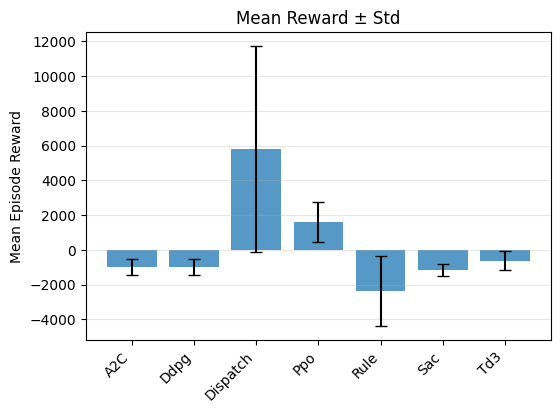

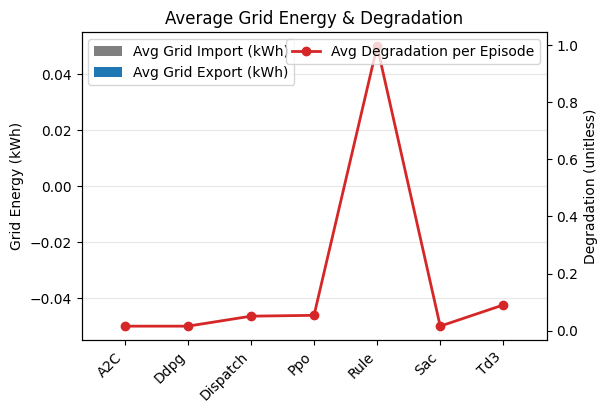

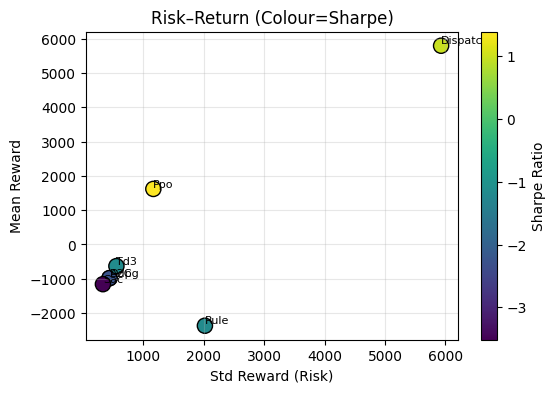

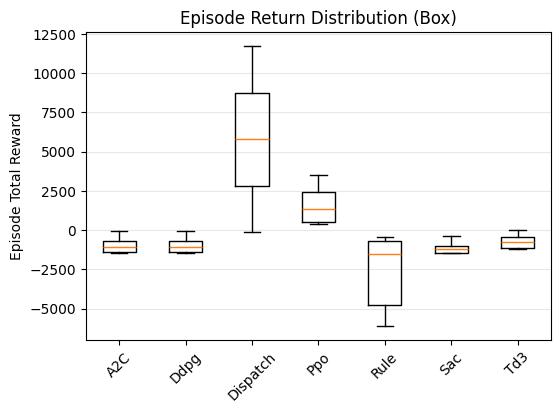

Saved evaluation metrics to: /code/eval_output/aemo_dt_compare/evaluation_metrics.csv


mean_reward,median_reward,std_reward,pct_5_reward,pct_95_reward,max_reward,recommended_rtg,recommended_rtg_total_percentile,recommended_rtg_rtg0_percentile,recommended_return_scale,recommended_raw_rtg_percentile,sharpe_ratio,sortino_ratio,var_5,cvar_5,avg_grid_import,avg_grid_export,avg_grid_net,avg_degradation_per_episode,avg_degradation_per_step,deg_incident_rate,avg_battery_flow_energy,avg_battery_flow_per_step,avg_total_revenue_per_episode,avg_total_degradation_cost_per_episode,avg_profit_per_episode,avg_energy_revenue_per_episode,avg_fcas_revenue_per_episode,avg_actual_energy_per_episode,avg_actual_energy_per_step,avg_battery_dispatch_abs_per_episode,avg_battery_dispatch_abs_per_step,avg_total_revenue_end,avg_total_degradation_cost_end,avg_total_degradation_end,episodes_evaluated,episodes_with_reward,avg_episode_steps,experiment
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,i64,f64,str
-986.960501,-1068.311455,438.617416,-1420.309698,-87.119193,-77.42344,-77.42344,-87.119193,0.84483,1.0,0.84483,-2.250163,-2.250163,-1420.309698,-1421.768449,0.0,0.0,0.0,0.015944,1.0111e-7,0.0,0.0,0.0,602533.759852,12784.258256,589749.501596,163.480082,602370.27977,-3.0,-0.000019,36.0,0.000228,602533.759852,12784.258256,0.015944,20,20,157680.0,"""A2C"""
-983.036708,-1057.896034,438.880855,-1421.213699,-77.283036,-66.84807,-66.84807,-77.283036,1.589615,1.0,1.589615,-2.239871,-2.239871,-1421.213699,-1426.301052,0.0,0.0,0.0,0.015944,1.0111e-7,0.0,0.0,0.0,606457.553108,12784.258256,593673.294853,294.830903,606162.722205,-3.0,-0.000019,36.0,0.000228,606457.553108,12784.258256,0.015944,20,20,157680.0,"""Ddpg"""
5796.30543,5796.30543,5928.917138,460.280006,11132.330853,11725.222567,11725.222567,11132.330853,11.55816,1.155816,11.55816,0.977633,NaN,460.280006,-132.611708,0.0,0.0,0.0,0.050902,3.2282e-7,0.0,0.0,0.0,7.4458e6,721665.581964,6.7242e6,5.3516e6,2.0942e6,32.857506,0.000208,184671.549564,1.171179,7.4458e6,721665.581964,0.050902,2,2,157680.0,"""Dispatch"""
1618.506581,1356.642483,1164.548774,412.116323,3499.232153,3534.267948,3534.267948,3499.232153,3.013902,1.0,3.013902,1.389814,NaN,412.116323,400.262298,0.0,0.0,0.0,0.053862,3.4159e-7,0.0,0.0,0.0,1.6798e6,42947.403832,1.6368e6,263324.486467,1.4165e6,-2.244401,-0.000014,3622.629234,0.022975,1.6798e6,42947.403832,0.053862,20,20,157680.0,"""Ppo"""
-2372.839412,-1507.371814,2018.323189,-5961.752815,-625.266977,-459.805529,-459.805529,-625.266977,5.911615,1.0,5.911615,-1.175649,-1.175649,-5961.752815,-6050.236813,0.0,0.0,0.0,0.996246,0.000009,0.0,0.0,0.0,554025.59036,2.5248e6,-1.9708e6,554025.59036,0.0,-8.920268,-0.000079,345396.346473,3.126882,554025.59036,2.5248e6,0.996246,60,60,116137.05,"""Rule"""
-1160.356935,-1210.715358,329.957872,-1473.615575,-382.515595,-381.415736,-381.415736,-382.515595,1.105012,1.0,1.105012,-3.516682,-3.516682,-1473.615575,-1476.047163,0.0,0.0,0.0,0.015944,1.0112e-7,0.0,0.0,0.0,429005.993463,12784.428458,416221.565005,212.675127,428793.318336,-3.0,-0.000019,43.08523,0.000273,429005.993463,12784.428458,0.015944,20,20,157680.0,"""Sac"""
-633.900022,-766.29316,553.013471,-1180.239523,579.388138,598.39593,598.39593,579.388138,0.827559,1.0,0.827559,-1.146265,-2.150957,-1180.239523,-1180.495762,0.0,0.0,0.0,0.090243,5.7232e-7,0.0,0.0,0.0,752555.53994,72280.561856,680274.978084,83997.294817,668558.245123,-2.626869,-0.000017,19290.04192,0.122337,752555.53994,72280.561856,0.090243,20,20,157680.0,"""Td3"""


In [4]:
# Evaluate the policy-grouped AEMO trajectories and save the metrics table.
metrics = evaluate_experiments(grouped_logs, target_return=0.0, save_dir=str(EVAL_OUTPUT_DIR))
metrics_csv_path = EVAL_OUTPUT_DIR / 'evaluation_metrics.csv'
metrics.write_csv(str(metrics_csv_path))

print(f'Saved evaluation metrics to: {metrics_csv_path}')
metrics

In [ ]:
# Recommended RTG / return-scale summary.
best_overall_rtg = float(metrics['recommended_rtg'].max()) if 'recommended_rtg' in metrics.columns else 0.0
best_return_scale = float(metrics['recommended_return_scale'].max()) if 'recommended_return_scale' in metrics.columns else 1.0

print(f'Best recommended RTG across policy groups: {best_overall_rtg}')
print(f'Best recommended return scale across policy groups: {best_return_scale}')

summary_cols = [
    'experiment',
    'mean_reward',
    'std_reward',
    'recommended_rtg',
    'recommended_return_scale',
    'var_5',
    'cvar_5',
]
existing_cols = [col for col in summary_cols if col in metrics.columns]
summary_table = metrics.select(existing_cols).sort('mean_reward', descending=True)
print(summary_table.to_pandas().to_string(index=False))

Best recommended RTG across policy groups: 11725.222567105191
Best recommended return scale across policy groups: 1.155816010723905
experiment  mean_reward  std_reward  recommended_rtg  recommended_return_scale        var_5       cvar_5
  Dispatch  5796.305430 5928.917138     11725.222567                  1.155816   460.280006  -132.611708
       Ppo  1618.506581 1164.548774      3534.267948                  1.000000   412.116323   400.262298
       Td3  -633.900022  553.013471       598.395930                  1.000000 -1180.239523 -1180.495762
      Ddpg  -983.036708  438.880855       -66.848070                  1.000000 -1421.213699 -1426.301052
       A2C  -986.960501  438.617416       -77.423440                  1.000000 -1420.309698 -1421.768449
       Sac -1160.356935  329.957872      -381.415736                  1.000000 -1473.615575 -1476.047163
      Rule -2372.839412 2018.323189      -459.805529                  1.000000 -5961.752815 -6050.236813


In [ ]:
# Bootstrap confidence intervals on the policy-grouped AEMO trajectories.
cis = bootstrap_confidence_intervals(
    grouped_logs,
    n_bootstrap=1000,
    confidence_level=0.95,
    seed=42,
)

for label, ci in sorted(cis.items()):
    print(
        f"{label:>12s}: mean={ci['mean']:+.2f}  95% CI=[{ci['ci_lower']:+.2f}, {ci['ci_upper']:+.2f}]  std={ci['std']:.2f}"
    )

         A2C: mean=-990.39  95% CI=[-1180.70, -802.61]  std=98.18
        Ddpg: mean=-983.84  95% CI=[-1171.27, -784.44]  std=97.44
    Dispatch: mean=+5766.66  95% CI=[-132.61, +11725.22]  std=4256.82
         Ppo: mean=+1631.14  95% CI=[+1153.45, +2122.03]  std=250.99
        Rule: mean=-2375.47  95% CI=[-2903.01, -1862.88]  std=263.35
         Sac: mean=-1157.29  95% CI=[-1300.09, -1000.43]  std=76.53
         Td3: mean=-631.51  95% CI=[-853.14, -386.34]  std=124.01
